In [ ]:
from transformers import AutoModel, AutoProcessor
from PIL import Image
import torch
import pandas as pd

pd.set_option('display.max_columns', None)

In [ ]:
model = AutoModel.from_pretrained("openai/clip-vit-base-patch32")
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")

weights = model.state_dict()

print(weights['logit_scale'])

tensor(4.6052)


In [ ]:
url ="/content/3F8D6D70-CA70-4828-8F7D-74B3380C1E04.jpeg"
image = Image.open(url)
text  = ["photo of banana", "photo of beach", "photo of a dessert","photo of me", "photo of laptop"]

inputs = processor(images = image, text = text, return_tensors = "pt", padding = True)

In [ ]:
import torch

with torch.inference_mode():
    outputs = model(**inputs)

In [ ]:
outputs.keys()

odict_keys(['logits_per_image', 'logits_per_text', 'text_embeds', 'image_embeds', 'text_model_output', 'vision_model_output'])

In [ ]:
outputs.logits_per_image

tensor([[21.0806, 26.4923, 21.3253, 20.6358, 19.9704]])

In [ ]:
old = outputs.image_embeds

In [ ]:
new = outputs.image_embeds

In [ ]:
old==new

tensor([[True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, T

In [ ]:
ans = outputs.logits_per_image


In [ ]:
ans_prob = torch.exp(ans) / torch.sum(torch.exp(ans))
ans_prob


tensor([[0.0044, 0.9857, 0.0056, 0.0028, 0.0014]])

In [ ]:
torch.cuda.is_available()  # True/False
torch.cuda.get_device_name(0)  # which GPU, if any

'Tesla T4'

In [ ]:
!pip install awscli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 8.8 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [ ]:
!aws s3 ls --no-sign-request s3://amazon-berkeley-objects/

                           PRE 3dmodels/
                           PRE archives/
                           PRE benchmarks/
                           PRE images/
                           PRE listings/
                           PRE spins/
                           PRE static_html/
2023-06-26 11:36:14      14527 LICENSE-CC-BY-4.0.txt
2021-06-14 08:42:37      14527 LICENSE-CC-BY-NC-4.0.txt
2023-07-18 09:27:12       4132 README.md
2023-07-18 09:47:11      48296 index.html


In [ ]:
!aws s3 ls --no-sign-request s3://amazon-berkeley-objects/listings/metadata/

2021-06-16 17:41:07    5446000 listings_0.json.gz
2021-06-16 17:41:07    5350124 listings_1.json.gz
2021-06-16 17:41:07    5446138 listings_2.json.gz
2021-06-16 17:41:07    5390098 listings_3.json.gz
2021-06-16 17:41:07    5546055 listings_4.json.gz
2021-06-16 17:41:07    5581270 listings_5.json.gz
2021-06-16 17:41:07    5496890 listings_6.json.gz
2021-06-16 17:41:07    5428695 listings_7.json.gz
2021-06-16 17:41:07    5565097 listings_8.json.gz
2021-06-16 17:41:07    5497477 listings_9.json.gz
2021-06-16 17:41:08    5461223 listings_a.json.gz
2021-06-16 17:41:09    5409119 listings_b.json.gz
2021-06-16 17:41:09    5443388 listings_c.json.gz
2021-06-16 17:41:09    5413521 listings_d.json.gz
2021-06-16 17:41:09    5501262 listings_e.json.gz
2021-06-16 17:41:09    5460984 listings_f.json.gz


In [ ]:
!aws s3 cp --no-sign-request s3://amazon-berkeley-objects/listings/metadata/listings_0.json.gz "/AWS ABO"

download: s3://amazon-berkeley-objects/listings/metadata/listings_0.json.gz to ../AWS ABO/listings_0.json.gz


In [ ]:
!aws s3 cp --no-sign-request s3://amazon-berkeley-objects/images/metadata/images.csv.gz "/AWS ABO/images/"

download: s3://amazon-berkeley-objects/images/metadata/images.csv.gz to ../AWS ABO/images/images.csv.gz


In [ ]:
!aws s3 cp --no-sign-request s3://amazon-berkeley-objects/listings/metadata/listings_0.json.gz "/AWS ABO/listings/"

download: s3://amazon-berkeley-objects/listings/metadata/listings_0.json.gz to ../AWS ABO/listings/listings_0.json.gz


In [ ]:
image_df = pd.read_csv('/AWS ABO/images/images.csv.gz', compression='gzip')
image_df['path_mod'] = 's3://amazon-berkeley-objects/images/original/' + image_df['path']

# image_split = image_df['path'].str.split('/',expand=True)
# image_split[image_split.iloc[:,1].isnull()]

# series = pd.Series(['hello/there','hello-there'])
# exp = series.str.split('/', expand=True)
# exp.iloc[:,1].isnull()

image_df.head()

,image_id,height,width,path,path_mod
0,010-mllS7JL,106,106,14/14fe8812.jpg,s3://amazon-berkeley-objects/images/original/1...
1,01dkn0Gyx0L,122,122,da/daab0cad.jpg,s3://amazon-berkeley-objects/images/original/d...
2,01sUPg0387L,111,111,d2/d2daaae9.jpg,s3://amazon-berkeley-objects/images/original/d...
3,1168jc-5r1L,186,186,3a/3a4e88e6.jpg,s3://amazon-berkeley-objects/images/original/3...
4,11RUV5Fs65L,30,500,d9/d91ab9cf.jpg,s3://amazon-berkeley-objects/images/original/d...


,0,1


,1
0,False
1,True


In [ ]:
import gzip
import json
import pandas as pd

data = []
with gzip.open('/AWS ABO/listings/listings_0.json.gz', 'rt', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

In [ ]:
df.columns

Index(['brand', 'bullet_point', 'color', 'item_id', 'item_name', 'model_name',
       'model_number', 'model_year', 'product_type', 'style', 'main_image_id',
       'other_image_id', 'item_keywords', 'country', 'marketplace',
       'domain_name', 'node', 'item_dimensions', 'item_weight', 'material',
       'fabric_type', 'color_code', 'product_description', 'spin_id',
       '3dmodel_id', 'pattern', 'finish_type', 'item_shape'],
      dtype='object')

In [ ]:
import gzip
import json
from collections import Counter

lang_counts = Counter()

with gzip.open('/AWS ABO/listings/listings_0.json.gz', 'rt', encoding='utf-8') as f:
    for line in f:
        raw_row = json.loads(line)
        brand_value = raw_row.get('brand')

        if not isinstance(brand_value, list):
            continue  # skip rows where brand is missing/NaN entirely

        for pair in brand_value:
            tag = pair.get('language_tag')
            if tag:
                lang_counts[tag] += 1

lang_counts.most_common()  # sorted list of (language_tag, count) tuples

[('en_IN', 4801),
 ('en_US', 1549),
 ('en_CA', 418),
 ('en_GB', 348),
 ('es_MX', 309),
 ('es_ES', 286),
 ('de_DE', 279),
 ('ja_JP', 263),
 ('fr_FR', 257),
 ('it_IT', 244),
 ('en_AU', 122),
 ('nl_NL', 102),
 ('en_AE', 94),
 ('en_SG', 89),
 ('pt_PT', 64),
 ('sv_SE', 57),
 ('tr_TR', 23),
 ('ar_AE', 20),
 ('zh_CN', 2),
 ('pl_PL', 1)]

In [ ]:
import gzip
import json
import pandas as pd

english_tags = {'en_US', 'en_GB', 'en_IN', 'en_AU', 'en_AE', 'en_CA', 'en_SG'}
# ^ verify this against real language_tag values you've seen — don't trust this list blindly

def extract_lang_field(raw_row, key, language_codes, join_multi=False):
    key_value = raw_row.get(key)
    if not isinstance(key_value, list):
        return ''
    matches = [pair['value'] for pair in key_value if pair.get('language_tag') in language_codes]
    if not matches:
        return ''
    return ' | '.join(matches) if join_multi else matches[0]

def extract_value_only(raw_row, key):
    # for columns like product_type, model_number: list of {'value': ...}, no language_tag at all
    key_value = raw_row.get(key)
    if not isinstance(key_value, list) or len(key_value) == 0:
        return ''
    return key_value[0].get('value', '')

def extract_raw(raw_row, key):
    # for plain scalar columns: item_id, country, marketplace, domain_name, main_image_id
    value = raw_row.get(key)
    return value if value is not None else ''

language_cols = {
    'brand': False,
    'bullet_point': True,
    'color': False,
    'item_name': False,
    'model_name': False,
    'style': False,
    'item_keywords': True,
    'material': True,
}
value_only_cols = ['product_type', 'model_number']
raw_cols = ['item_id', 'country', 'marketplace', 'domain_name', 'main_image_id']

data = []

with gzip.open('/AWS ABO/listings/listings_0.json.gz', 'rt', encoding='utf-8') as f:
    for line in f:
        raw_row = json.loads(line)
        mod_row = {}

        for col, multi in language_cols.items():
            mod_row[col] = extract_lang_field(raw_row, col, english_tags, join_multi=multi)

        for col in value_only_cols:
            mod_row[col] = extract_value_only(raw_row, col)

        for col in raw_cols:
            mod_row[col] = extract_raw(raw_row, col)

        data.append(mod_row)

df_final = pd.DataFrame(data)
brands_df = df_final.copy()

In [ ]:
df_final.columns

Index(['brand', 'bullet_point', 'color', 'item_name', 'model_name', 'style',
       'item_keywords', 'material', 'product_type', 'model_number', 'item_id',
       'country', 'marketplace', 'domain_name', 'main_image_id'],
      dtype='object')

In [ ]:
brands_img = brands_df.merge(image_df, left_on='main_image_id', right_on = 'image_id')
brands_img = brands_img[brands_img['image_id']!= None]
brands_img[['brand','main_image_id','image_id','path_mod']].sample(5)


,brand,main_image_id,image_id,path_mod
2290,Amazon Brand - Solimo,71uH+BQC2VL,71uH+BQC2VL,s3://amazon-berkeley-objects/images/original/6...
3754,Amazon Brand - Solimo,81+eY4EoWUL,81+eY4EoWUL,s3://amazon-berkeley-objects/images/original/5...
7098,Amazon Brand - Solimo,81lfTINTyRL,81lfTINTyRL,s3://amazon-berkeley-objects/images/original/e...
5634,Amazon Brand - Solimo,71b6VPIJxyL,71b6VPIJxyL,s3://amazon-berkeley-objects/images/original/7...
4823,,61DQzvS159L,61DQzvS159L,s3://amazon-berkeley-objects/images/original/4...


In [ ]:
!aws s3 cp --no-sign-request s3://amazon-berkeley-objects/images/original/4b/4b27d7c1.jpg "/AWS ABO/original_image/"

download: s3://amazon-berkeley-objects/images/original/4b/4b27d7c1.jpg to ../AWS ABO/original_image/4b27d7c1.jpg


download: s3://amazon-berkeley-objects/images/original/97/9704905f.jpg to ../AWS ABO/original_image/9704905f.jpg


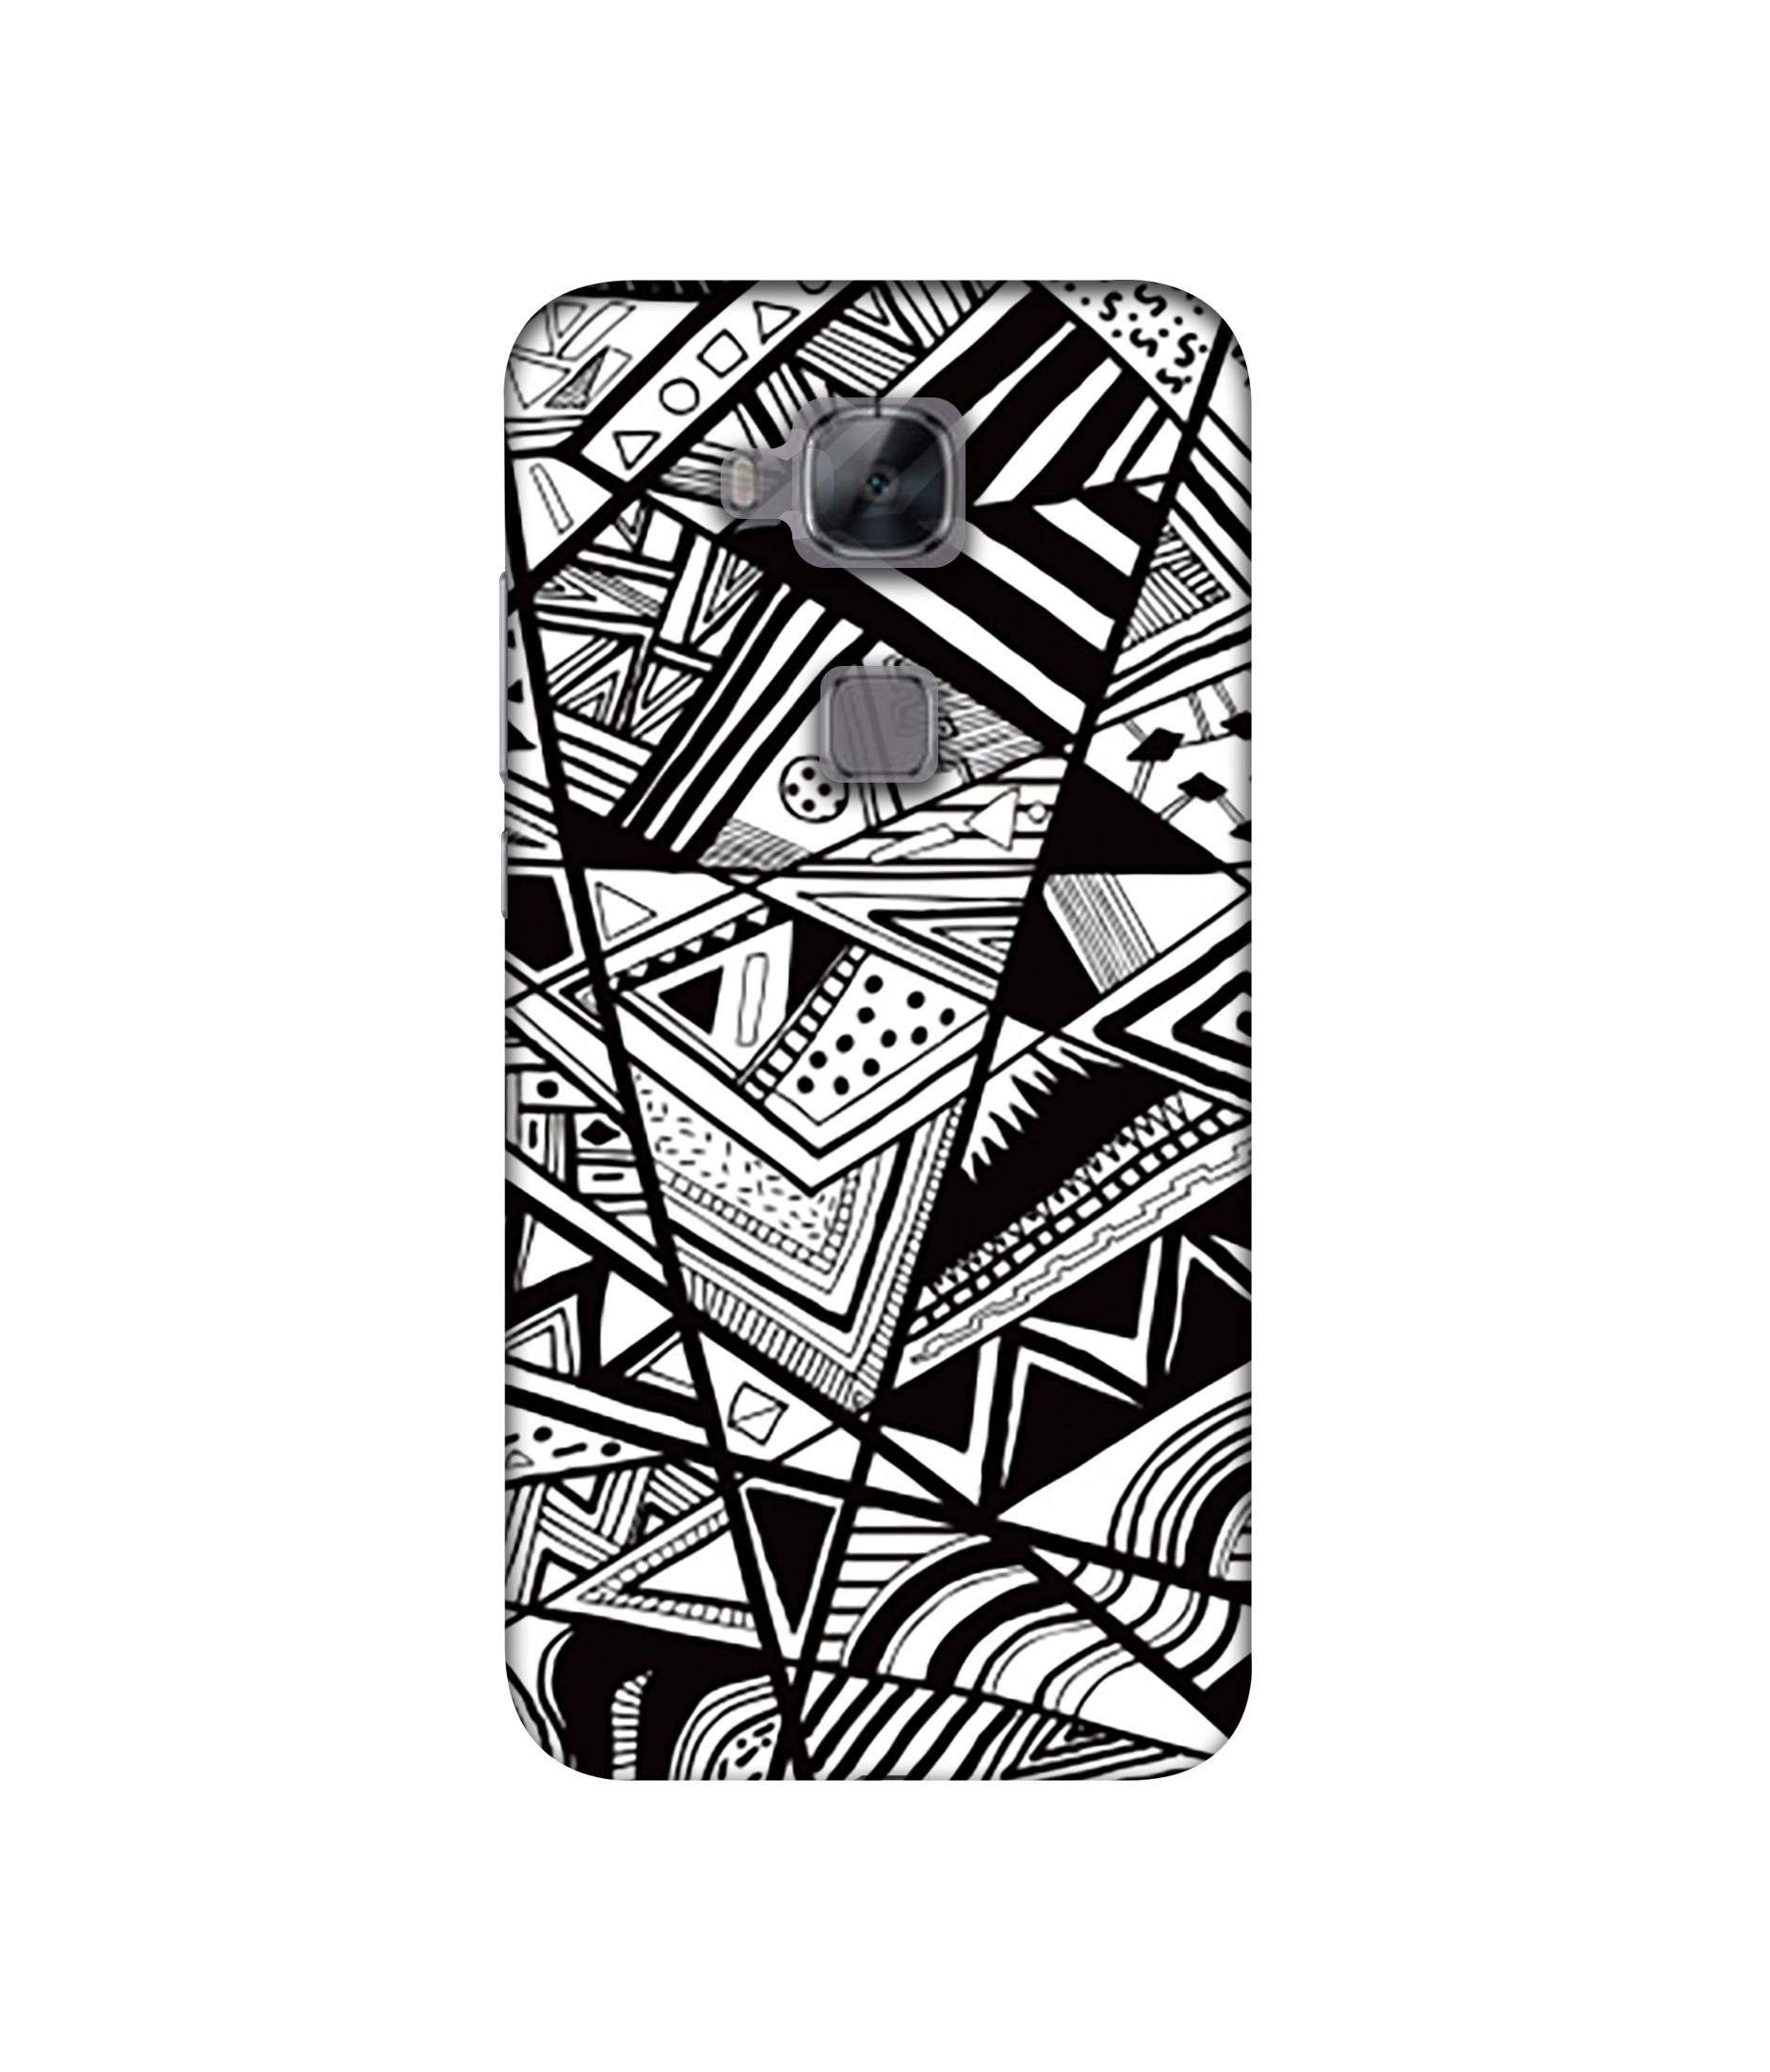

In [ ]:
from IPython import get_ipython

def run_ipython_magic(magic_line):
    ipython = get_ipython()
    code = ipython.transform_cell(magic_line)
    exec(code)

def get_image_to_df(image_path):

  code = f'!aws s3 cp --no-sign-request s3://amazon-berkeley-objects/images/original/{image_path} "/AWS ABO/original_image/"'
  run_ipython_magic(code)

  image_name = image_path.rsplit('/')[1]
  local_image_path = f"/AWS ABO/original_image/{image_name}"
  image = Image.open(local_image_path)
  return image

get_image_to_df('97/9704905f.jpg')

In [ ]:
sample_data = brands_img.sample(20).copy().reset_index()
images = []
for path in sample_data['path']:
  print(path)
  images.append(get_image_to_df(path))
images = pd.Series(images)
sample_data = pd.concat([sample_data,images],axis=1)
sample_data.head(1)

e9/e979c15d.jpg
download: s3://amazon-berkeley-objects/images/original/e9/e979c15d.jpg to ../AWS ABO/original_image/e979c15d.jpg
28/2862e0f1.jpg
download: s3://amazon-berkeley-objects/images/original/28/2862e0f1.jpg to ../AWS ABO/original_image/2862e0f1.jpg
18/18d803af.jpg
download: s3://amazon-berkeley-objects/images/original/18/18d803af.jpg to ../AWS ABO/original_image/18d803af.jpg
a5/a57e2a6e.jpg
download: s3://amazon-berkeley-objects/images/original/a5/a57e2a6e.jpg to ../AWS ABO/original_image/a57e2a6e.jpg
a5/a54b5a17.jpg
download: s3://amazon-berkeley-objects/images/original/a5/a54b5a17.jpg to ../AWS ABO/original_image/a54b5a17.jpg
f5/f5e14a91.jpg
download: s3://amazon-berkeley-objects/images/original/f5/f5e14a91.jpg to ../AWS ABO/original_image/f5e14a91.jpg
f5/f5297ebf.jpg
download: s3://amazon-berkeley-objects/images/original/f5/f5297ebf.jpg to ../AWS ABO/original_image/f5297ebf.jpg
bb/bb8daed5.jpg
download: s3://amazon-berkeley-objects/images/original/bb/bb8daed5.jpg to ../AWS 

AttributeError: 'DataFrame' object has no attribute 'concat'

,index,brand,bullet_point,color,item_name,model_name,style,item_keywords,material,product_type,model_number,item_id,country,marketplace,domain_name,main_image_id,image_id,height,width,path,path_mod,0,0
0,653,Amazon Brand - Solimo,"3D Printed Hard Back Case Mobile Cover for Oppo A37 | Easy to put & take off with perfect cutouts for volume buttons, audio & charging ports. | Stylish design and appearance, express your unique personality. | Extreme precision design allows easy access to all buttons and ports while featuring raised bezel to life screen and camera off flat surface. | Slim Hard Back Cover | No Warranty",Others,Amazon Brand - Solimo Designer Love 3D Printed Hard Back Case Mobile Cover for Oppo A37,Oppo A37,,mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | LG mobile case | LG phone cover | LG back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover,,CELLULAR_PHONE_CASE,gz8355-SL40543,B07TF1H214,IN,Amazon,amazon.in,8152J306A-L,8152J306A-L,2200.0,1879.0,e9/e979c15d.jpg,s3://amazon-berkeley-objects/images/original/e9/e979c15d.jpg,NaN,<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1879x2200 at 0x7E4909BE1A90>


In [ ]:
sample_data.head(1)

,brand,bullet_point,color,item_name,model_name,style,item_keywords,material,product_type,model_number,item_id,country,marketplace,domain_name,main_image_id,image_id,height,width,path,path_mod,0
653,Amazon Brand - Solimo,"3D Printed Hard Back Case Mobile Cover for Oppo A37 | Easy to put & take off with perfect cutouts for volume buttons, audio & charging ports. | Stylish design and appearance, express your unique personality. | Extreme precision design allows easy access to all buttons and ports while featuring raised bezel to life screen and camera off flat surface. | Slim Hard Back Cover | No Warranty",Others,Amazon Brand - Solimo Designer Love 3D Printed Hard Back Case Mobile Cover for Oppo A37,Oppo A37,,mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | LG mobile case | LG phone cover | LG back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover | mobile cover | back cover | mobile case | phone case | mobile panel | phone panel | Oppo mobile case | Oppo phone cover | Oppo back case | hard case | 3D printed mobile cover,,CELLULAR_PHONE_CASE,gz8355-SL40543,B07TF1H214,IN,Amazon,amazon.in,8152J306A-L,8152J306A-L,2200.0,1879.0,e9/e979c15d.jpg,s3://amazon-berkeley-objects/images/original/e9/e979c15d.jpg,NaN


In [ ]:
!pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 853.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 2.9 MB/s eta 0:00:00


In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
from concurrent.futures import ThreadPoolExecutor, as_completed
import os

s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))
BUCKET = 'amazon-berkeley-objects'
LOCAL_DIR = '/AWS ABO/small_images'
os.makedirs(LOCAL_DIR, exist_ok=True)

def download_one(path):
    """path like '97/9704905f.jpg' -> downloads to LOCAL_DIR, returns local path or None on failure."""
    s3_key = f'images/small/{path}'
    local_path = os.path.join(LOCAL_DIR, path.replace('/', '_'))  # flatten subfolders into filename
    if os.path.exists(local_path):
        return local_path  # skip if already downloaded — makes reruns cheap
    try:
        s3.download_file(BUCKET, s3_key, local_path)
        return local_path
    except Exception as e:
        print(f"failed: {path} -> {e}")
        return None

def download_many(paths, max_workers=20):
    results = {}
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_path = {executor.submit(download_one, p): p for p in paths}
        for future in as_completed(future_to_path):
            path = future_to_path[future]
            results[path] = future.result()
    return results

# usage:
# paths = sample_data['path'].tolist()
# local_paths = download_many(paths)

ModuleNotFoundError: No module named 'boto3'

In [ ]:
sample_data = brands_img.sample(20).copy().reset_index()
paths = sample_data['path'].tolist()
local_paths = download_many(paths)
local_paths

{'c2/c2fb4737.jpg': '/AWS ABO/small_images/c2_c2fb4737.jpg',
 '02/028c2c72.jpg': '/AWS ABO/small_images/02_028c2c72.jpg',
 'f4/f4f31eec.jpg': '/AWS ABO/small_images/f4_f4f31eec.jpg',
 '84/84c92ca2.jpg': '/AWS ABO/small_images/84_84c92ca2.jpg',
 '8c/8ca84432.jpg': '/AWS ABO/small_images/8c_8ca84432.jpg',
 '87/874f86c4.jpg': '/AWS ABO/small_images/87_874f86c4.jpg',
 'e2/e2b31dd7.jpg': '/AWS ABO/small_images/e2_e2b31dd7.jpg',
 '66/66fdc898.jpg': '/AWS ABO/small_images/66_66fdc898.jpg',
 '28/28043ed3.jpg': '/AWS ABO/small_images/28_28043ed3.jpg',
 '02/02fc7390.jpg': '/AWS ABO/small_images/02_02fc7390.jpg',
 'f4/f4262f81.jpg': '/AWS ABO/small_images/f4_f4262f81.jpg',
 '24/24bbce51.jpg': '/AWS ABO/small_images/24_24bbce51.jpg',
 '4d/4df76eeb.jpg': '/AWS ABO/small_images/4d_4df76eeb.jpg',
 '25/2587d3bd.jpg': '/AWS ABO/small_images/25_2587d3bd.jpg',
 'f8/f8a6e4b5.jpg': '/AWS ABO/small_images/f8_f8a6e4b5.jpg',
 '21/21f6015b.jpg': '/AWS ABO/small_images/21_21f6015b.jpg',
 'b5/b57bb187.jpg': '/AW

In [ ]:
sample_data.head(1)

,index,brand,bullet_point,color,item_name,model_name,style,item_keywords,material,product_type,model_number,item_id,country,marketplace,domain_name,main_image_id,image_id,height,width,path,path_mod
0,54,Amazon Brand - Symbol,Outer Material: Pu | Product Type: Men's Forma...,Tan,Amazon Brand - Symbol Men's Tan PU Formal Shoe...,,Derby,formal shoes for mens leather | leather shoes ...,Synthetic,SHOES,,B07WG3V91C,IN,Amazon,amazon.in,814RXC4DgkL,814RXC4DgkL,1324,2517,f4/f4f31eec.jpg,s3://amazon-berkeley-objects/images/original/f...
